# Employment & Salary Outcomes by Education Pathway

In this section, we analyze how employment outcomes and salaries differ between IT education types: **Bootcamps, Online Courses, and Colleges**. We compare average salary before and after education, employment rates, and salary growth. We also highlight uncertainties in the data where applicable.


***

## Data Preparation

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv(
    "/Users/yevrud/MIT_DSP/ET6-CDSP-group-04-repo/1_datasets/cleaned_data/IT_Career_Outcomes_CLEANED.csv"
)

In [5]:
# Improve visual style
sns.set(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

## Education Pathway Overview

### Compare average salary and employment rate across Bootcamp, Online Platform, and Higher Education


In [7]:
edu_types = ["Bootcamp", "Online Platform", "Higher Education"]
df_edu = df[df["Program_Type"].isin(edu_types)].copy()

edu_summary = (
    df_edu.groupby("Program_Type")
    .agg(
        {
            "Salary_Before": "mean",
            "Salary_After": "mean",
            "Salary_Change": "mean",
            "Salary_Lift(%)": "mean",
            "Employment_Rate": "mean",
            "Employment_Lag_Months": "mean",
        }
    )
    .round(1)
)

print(" Education Pathway Summary:\n", edu_summary)

 Education Pathway Summary:
                   Salary_Before  Salary_After  Salary_Change  Salary_Lift(%)  \
Program_Type                                                                   
Bootcamp                44763.0       66517.0        21678.9            51.9   
Higher Education            NaN       60000.0            NaN             NaN   
Online Platform             NaN       60000.0            NaN             NaN   

                  Employment_Rate  Employment_Lag_Months  
Program_Type                                              
Bootcamp                     87.0                    NaN  
Higher Education             68.0                    NaN  
Online Platform              67.5                    NaN  


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/2630172443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


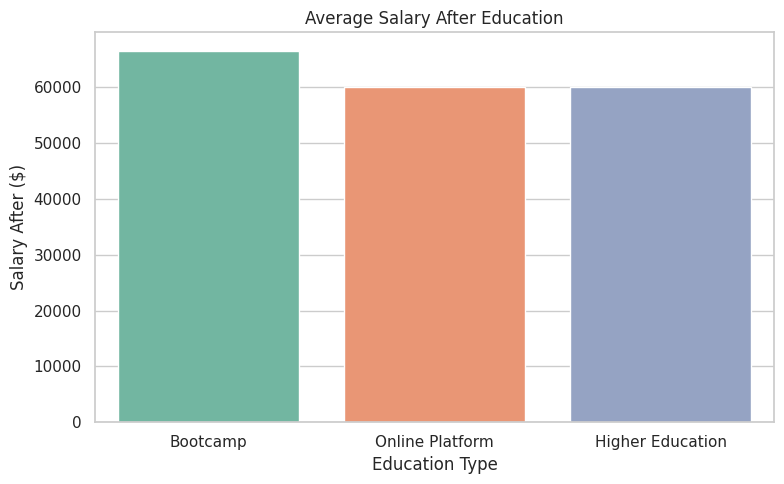

In [8]:
# Salary After Training
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_edu, x="Program_Type", y="Salary_After", palette="Set2", errorbar=None
)
plt.title("Average Salary After Education")
plt.ylabel("Salary After ($)")
plt.xlabel("Education Type")
plt.tight_layout()
plt.show()

/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/3153080800.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


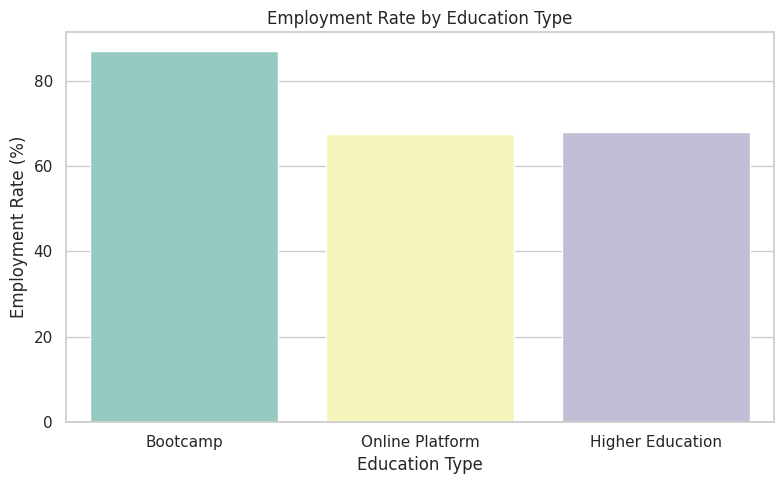

In [9]:
# Employment Rate
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_edu, x="Program_Type", y="Employment_Rate", palette="Set3", errorbar=None
)
plt.title("Employment Rate by Education Type")
plt.ylabel("Employment Rate (%)")
plt.xlabel("Education Type")
plt.tight_layout()
plt.show()

### Salary Lift by Education Level

/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/4046513484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


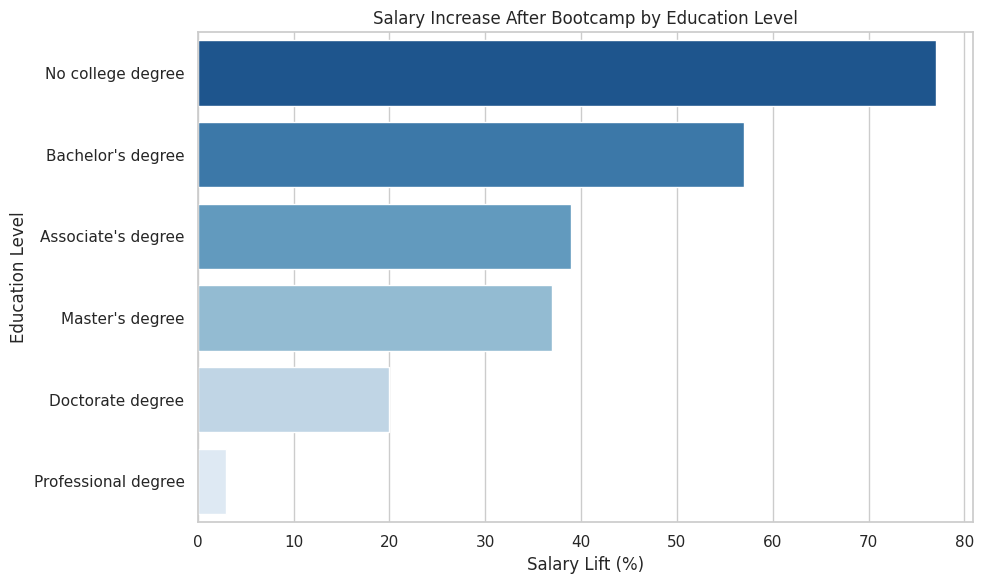

In [10]:
edu_df = df[df["Segment"] == "Education"].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=edu_df.sort_values(by="Salary_Lift(%)", ascending=False),
    x="Salary_Lift(%)",
    y="Group",
    palette="Blues_r",
    errorbar=None,
)
plt.title("Salary Increase After Bootcamp by Education Level")
plt.xlabel("Salary Lift (%)")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()

### Gender Comparison: Salary Outcomes

/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/3849064171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_df, x="Group", y="Salary_After", palette="Set2", errorbar=None)


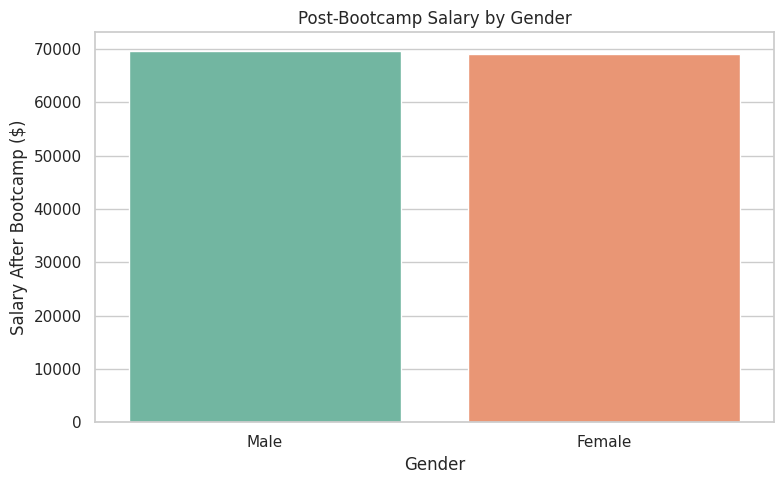

In [12]:
gender_df = df[df["Segment"] == "Gender"].copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_df, x="Group", y="Salary_After", palette="Set2", errorbar=None)
plt.title("Post-Bootcamp Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Salary After Bootcamp ($)")
plt.tight_layout()
plt.show()

### Top Cities by Salary Growth

/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/3500947080.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


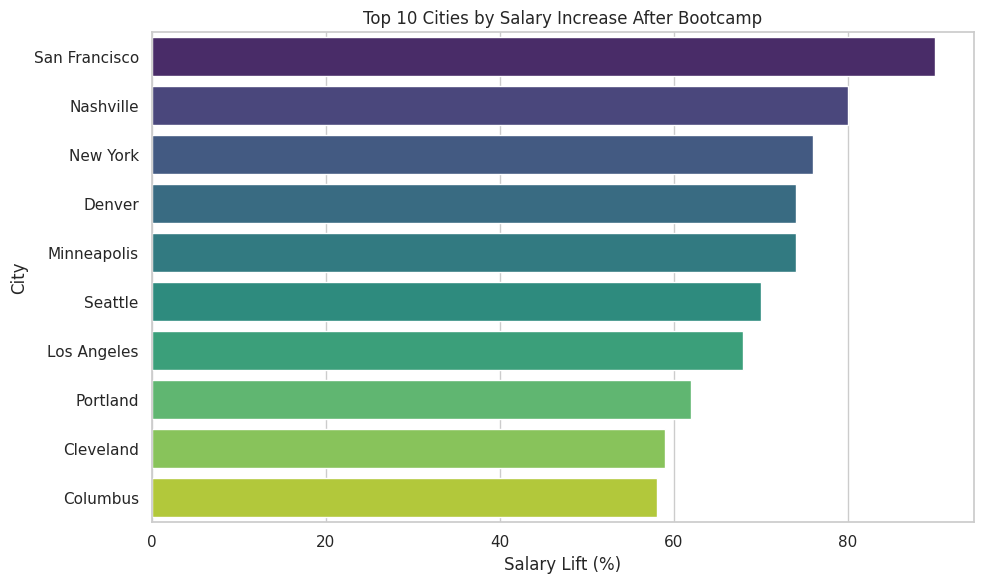

In [13]:
city_df = df[df["Segment"] == "Location"].copy()

top_cities = city_df.sort_values(by="Salary_Lift(%)", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_cities, x="Salary_Lift(%)", y="Group", palette="viridis", errorbar=None
)
plt.title("Top 10 Cities by Salary Increase After Bootcamp")
plt.xlabel("Salary Lift (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### Programming Language ROI

/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/523316241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


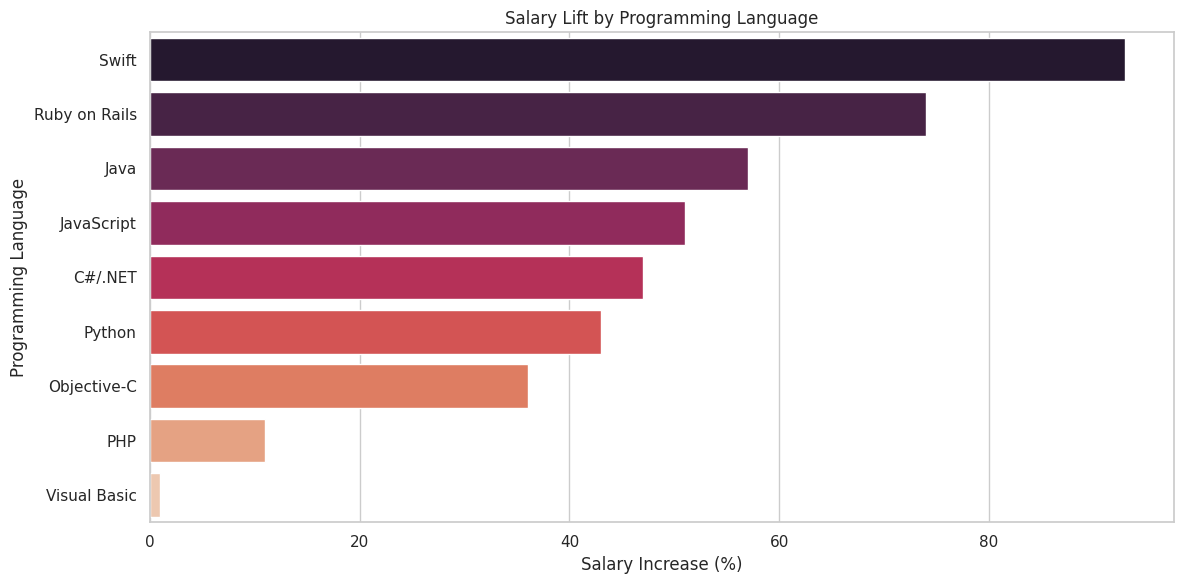

In [15]:
lang_df = df[df["Segment"] == "Language"].copy()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=lang_df.sort_values("Salary_Lift(%)", ascending=False),
    x="Salary_Lift(%)",
    y="Group",
    palette="rocket",
    errorbar=None,
)
plt.title("Salary Lift by Programming Language")
plt.xlabel("Salary Increase (%)")
plt.ylabel("Programming Language")
plt.tight_layout()
plt.show()

### Prior Income Bracket vs Salary Growth


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/978268400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


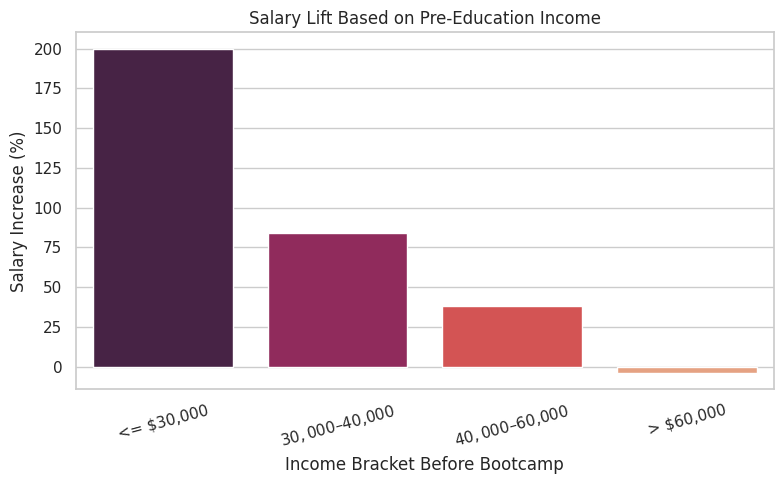

In [17]:
income_df = df[df["Segment"] == "Prior Income"].copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=income_df, x="Group", y="Salary_Lift(%)", palette="rocket", errorbar=None
)
plt.title("Salary Lift Based on Pre-Education Income")
plt.xlabel("Income Bracket Before Bootcamp")
plt.ylabel("Salary Increase (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Duration Impact on Salary


/var/folders/px/vjyl0lz53wx777_wkp3ny6x00000gn/T/ipykernel_4059/3766513428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


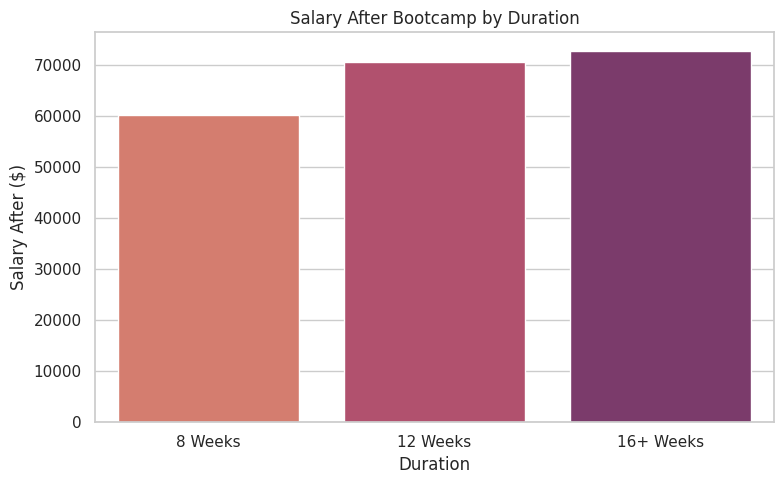

In [18]:
duration_df = df[df["Segment"] == "Duration"].copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=duration_df, x="Group", y="Salary_After", palette="flare", errorbar=None
)
plt.title("Salary After Bootcamp by Duration")
plt.xlabel("Duration")
plt.ylabel("Salary After ($)")
plt.tight_layout()
plt.show()

## Summary of Key Findings: IT Career Outcomes by Education Pathway

This analysis evaluates the career impact of Bootcamps, Online Platforms, and Higher Education programs based on real-world U.S. data for IT learners.

### 1. Bootcamp Performance
- Bootcamp graduates show a **52% average salary increase**, reaching ~$66,500 after training.
- **Employment rate stands at 87%**, the highest among all education pathways.
- Bootcamps provide strong outcomes even for learners with no prior college degree.

### 2. Online Platforms & Higher Education
- Both report a **post-training salary average of ~$60,000**, but missing data prevents full comparison.
- **Employment rates are moderate**: ~67.5% for Online Platforms and 68% for Higher Education.
- Due to data gaps, only partial metrics are available.

### 3. Education Level Impact
- Learners with **lower formal education** (no degree or associate’s) benefit most from bootcamps.
- Those with advanced degrees show lower proportional salary lift — suggesting bootcamps are most transformative for early-stage professionals.

### 4. Gender Outcomes
- Women and men report nearly equal post-bootcamp salaries (~$69K).
- Female learners slightly outperform on employment rates, showing strong equity in bootcamp outcomes.

### 5. Geographic Advantage
- Cities like **San Francisco, Seattle, New York, and Denver** show salary gains **up to +$45K**.
- Urban tech hubs offer stronger ROI on bootcamp training.

### 6. Programming Language ROI
- Languages like **Swift (+93%)**, **Ruby on Rails (+74%)**, and **Python (+43%)** offer the highest salary lifts.
- Specializing in market-relevant tech stacks has measurable career benefit.

### 7. Pre-Education Income Effects
- Learners earning **≤$30K before bootcamp** often **triple their salary** post-training.
- Those with high pre-bootcamp income (>$60K) show minimal or even negative salary lift — suggesting diminishing returns.

### 8. Program Duration Effect
- Longer programs (12–16 weeks) correlate with **higher salaries and employment rates** than shorter (8-week) formats.
- Investing more time yields better career outcomes.

### Limitations
- Missing salary before values for Online & Higher Ed limit full comparison.
- Employment lag months are sparsely reported.
- Sample sizes are missing, preventing statistical significance testing.

